## **PV generation Forecast Comparisions**

- **Data**: pv_generation 
- **Models**: Persistence, SARIMA, XGBoost and  LSTM(with different preprocessors and hyperparameters).

### **Setup: path, imports, load data**

In [1]:
from pathlib import Path
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import sys
# Project root = folder that contains Data/ (and preprocessor/, forecast_models/)
ROOT = Path.cwd() if (Path.cwd() / "Data").exists() else Path.cwd().parent
if not (ROOT / "Data").exists():
    raise FileNotFoundError("Data folder not found. Run notebook from project root or forecast_implementation.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
from forecast_implementation.forecast_helper import compare_models_on_test, evaluate_model, evaluate_model_rolling, run_pipelines_hyperparam_rolling, run_pipelines_hyperparam, rmse, mape, r2, set_seed,mbe,best_model_test_forecast,get_test_forecast,format_for_csv
from preprocessor import *
from forecast_models import *

In [2]:
SAVE = True

In [3]:
set_seed(42)

In [4]:
DATA_DIR = ROOT / "Data"
pv_raw = pd.read_csv(DATA_DIR / "pv_generated_hourly.csv", index_col=0, parse_dates=True)
pv_raw = pv_raw.rename(columns={"Wert": "pv_generation"})

In [5]:
pv_raw.head()

,pv_generation
2024-01-01 00:00:00,0.0
2024-01-01 01:00:00,0.0
2024-01-01 02:00:00,0.0
2024-01-01 03:00:00,0.0
2024-01-01 04:00:00,0.0


In [6]:
pv_raw["pv_generation"] = pv_raw["pv_generation"].clip(lower=0)

In [7]:
splitter = get_date_splitter("electricity", config_path=ROOT / "split_config.csv")

In [8]:
# Add temperature from Open-Meteo (WeatherFeatures) for SARIMAX / exog use

weather = WeatherFeatures(latitude=54.322933, longitude=9.615820, variables=["temperature_2m"]) # Büsumer Straße 135-137, 24768 Rendsburg, Germany
weather.fit(pv_raw)
df_pv_temp = weather.transform(pv_raw).rename(columns={"temperature_2m": "temperature"})
df_pv_temp.head()

,pv_generation,temperature
2024-01-01 00:00:00,0.0,5.5
2024-01-01 01:00:00,0.0,5.5
2024-01-01 02:00:00,0.0,5.3
2024-01-01 03:00:00,0.0,5.4
2024-01-01 04:00:00,0.0,5.2


In [9]:
df_pv_temp.corr()

,pv_generation,temperature
pv_generation,1.000000,0.567282
temperature,0.567282,1.000000


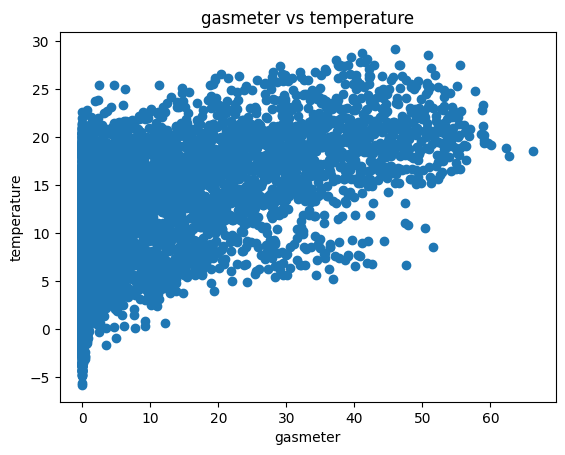

In [10]:
import matplotlib.pyplot as plt

plt.scatter(df_pv_temp["pv_generation"], df_pv_temp["temperature"])
plt.xlabel("gasmeter")
plt.ylabel("temperature")
plt.title("gasmeter vs temperature")
plt.show()

In [11]:

weather = WeatherFeatures(latitude=54.322933, longitude=9.615820, variables=["shortwave_radiation"]) # Büsumer Straße 135-137, 24768 Rendsburg, Germany
weather.fit(pv_raw)
df_pv_ghi = weather.transform(pv_raw).rename(columns={"shortwave_radiation": "GHI"})
df_pv_ghi.head()

,pv_generation,GHI
2024-01-01 00:00:00,0.0,0.0
2024-01-01 01:00:00,0.0,0.0
2024-01-01 02:00:00,0.0,0.0
2024-01-01 03:00:00,0.0,0.0
2024-01-01 04:00:00,0.0,0.0


In [12]:
df_pv_ghi.corr()

,pv_generation,GHI
pv_generation,1.000000,0.903356
GHI,0.903356,1.000000


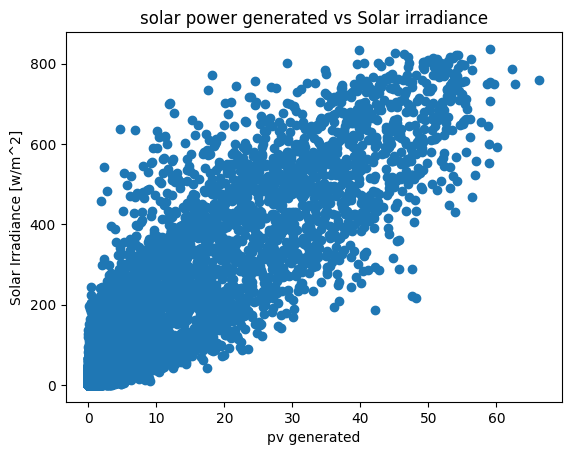

In [13]:
import matplotlib.pyplot as plt

plt.scatter(df_pv_ghi["pv_generation"], df_pv_ghi["GHI"])
plt.xlabel("pv generated")
plt.ylabel("Solar Irradiance [w/m^2]")
plt.title("solar power generated vs Solar irradiance")
plt.show()

### **Persistence Model**

In [14]:
pipelines_persistence = [
    {"model_type": "forecast", 
    "preprocessing": [], 
    "splitter": splitter,
     "model": lambda **kw: PersistenceModel(period=24), 
     "hyperparams": {}}]

In [15]:
results_persistence, best_hp_persistence, best_prep_persistence = run_pipelines_hyperparam(pv_raw, pipelines_persistence, {"rmse":rmse,"mbe":mbe})


Running pipeline 1


In [16]:
results_persistence

,pipeline_idx,preprocessing,rmse,mbe,elapsed_sec,train_rmse,train_mbe
0,1,,14.662362,6.582708,0.000575,5.49528,8.178438e-19


### **SARIMA Model**

In [17]:
def generate_order_combinations(p_range, d_range, q_range):
    return list(itertools.product(p_range, d_range, q_range))

In [18]:
pipeline1 = {
    "model_type": "forecast",
    "preprocessing": [LogTransform()],
    "splitter": splitter,
    "model": SARIMA_Model,
    "hyperparams": {
        "order": [(p,d,q) for p,d,q in generate_order_combinations(range(0,2), range(0,2), range(0,2))],#[(1,0,0), (2,0,0),(1,1,0)],#
        "seasonal_order": [(1,0,0,24), (0,0,1,24), (1,0,1,24)]
    }
}

pipeline2 = {
    "model_type": "forecast",
    "preprocessing": [],
    "splitter": splitter,
    "model": SARIMA_Model,
    "hyperparams": {
        "order": [(p,d,q) for p,d,q in generate_order_combinations(range(0,2), range(0,2), range(0,2))],#[(1,0,0), (2,0,0),(1,1,0)],#
        "seasonal_order": [(1,0,0,24), (0,0,1,24), (1,0,1,24)]  # (2,0,1,24) removed: MemoryError
    }
}

pipeline_sarimax = {
    "model_type": "forecast",
    "preprocessing": [],  
    "splitter": splitter,
    "model": SARIMAX_Model,
    "hyperparams": {
        "order": [(p,d,q) for p,d,q in generate_order_combinations(range(0,2), range(0,2), range(0,2))],#[(1,0,0), (2,0,0),(1,1,0)],#
        "seasonal_order": [(1, 0, 1, 24)],
        "exog_col": ["temperature"],   
        "target_col": ["elecmeter"],   
    },
}

_orders_simple = [(0,0,0), (1,0,0), (0,0,1), (1,0,1)]
_seasonal_simple = [(p,d,q,24) for p,d,q in generate_order_combinations(range(0,2), range(0,2), range(0,2))]

pipeline1 = {
    "model_type": "forecast",
    "preprocessing": [LogTransform()],
    "splitter": splitter,
    "model": SARIMA_Model,
    "hyperparams": {"order": _orders_simple, "seasonal_order": _seasonal_simple}
}

pipeline2 = {
    "model_type": "forecast",
    "preprocessing": [],
    "splitter": splitter,
    "model": SARIMA_Model,
    "hyperparams": {"order": _orders_simple, "seasonal_order": _seasonal_simple}
}



sarima_piplines = [pipeline1, pipeline2]

In [19]:
results_SARIMA, best_hp_sarima, best_prep_sarima = run_pipelines_hyperparam(pv_raw["pv_generation"], sarima_piplines, {"rmse":rmse,"mbe":mbe})


Running pipeline 1

Running pipeline 2


In [20]:
results_SARIMA.sort_values("rmse", ascending=True, inplace=True)

In [21]:
results_SARIMA.head()

,pipeline_idx,preprocessing,order,seasonal_order,rmse,mbe,elapsed_sec,train_rmse,train_mbe
0,2,,"(1, 0, 0)","(0, 1, 1, 24)",9.951779,3.725005,6.522295,4.343425,-0.250316
1,2,,"(1, 0, 1)","(0, 1, 1, 24)",9.952028,3.725365,7.890115,4.343371,-0.248969
2,2,,"(1, 0, 0)","(1, 1, 1, 24)",9.952153,3.725573,12.322435,4.343409,-0.250292
3,2,,"(1, 0, 1)","(1, 1, 1, 24)",9.952515,3.726096,15.633447,4.343354,-0.248934
4,1,LogTransform,"(1, 0, 1)","(1, 1, 1, 24)",10.055549,3.489201,12.606478,4.373320,-0.506769


In [22]:
best_hp_sarima

{'order': (1, 0, 0), 'seasonal_order': (0, 1, 1, 24)}

In [27]:
format_for_csv(results_SARIMA.head().drop("preprocessing",axis=1)).sort_values("rmse")

,pipeline_idx,order,seasonal_order,rmse,mbe,elapsed_sec,train_rmse,train_mbe
4,1,"(1, 0, 1)","(1, 1, 1, 24)",10.06,3.49,12.61,4.37,-0.51
0,2,"(1, 0, 0)","(0, 1, 1, 24)",9.95,3.73,6.52,4.34,-0.25
1,2,"(1, 0, 1)","(0, 1, 1, 24)",9.95,3.73,7.89,4.34,-0.25
2,2,"(1, 0, 0)","(1, 1, 1, 24)",9.95,3.73,12.32,4.34,-0.25
3,2,"(1, 0, 1)","(1, 1, 1, 24)",9.95,3.73,15.63,4.34,-0.25


In [28]:
if SAVE:
    format_for_csv(results_SARIMA.head().drop("preprocessing",axis=1)).sort_values("rmse").to_csv(DATA_DIR/"pv_SARIMA_Summary.csv",index=False)

In [29]:
pipeline_sarimax = {
    "model_type": "forecast",
    "preprocessing": [],  
    "splitter": splitter,
    "model": SARIMAX_Model,
    "hyperparams": {
        "order": [best_hp_sarima['order']],
        "seasonal_order": [best_hp_sarima['seasonal_order']],
        "exog_col": ["GHI"],   
        "target_col": ["pv_generation"],   
    },
}

In [30]:
results_SARIMAX, best_hp_sarimax, best_prep_sarimax = run_pipelines_hyperparam(df_pv_ghi, [pipeline_sarimax], {"rmse":rmse,"mbe":mbe})


Running pipeline 1


In [31]:
results_SARIMAX.sort_values("rmse", ascending=True, inplace=True)
results_SARIMAX

,pipeline_idx,preprocessing,order,seasonal_order,exog_col,target_col,rmse,mbe,elapsed_sec,train_rmse,train_mbe
0,1,,"(1, 0, 0)","(0, 1, 1, 24)",GHI,pv_generation,6.611359,1.522422,11.961815,4.093412,-0.220368


In [33]:
def sarima_test_residuals_with_preproc(series, pipelines, best_hp):
    # Assume a single SARIMA pipeline in this list
    pipe = pipelines[0]
    splitter = pipe["splitter"]
    preprocessors = pipe.get("preprocessing", [])
    # 1) Split as in the comparison
    train_df, val_df, test_df = splitter(series)
    # 2) Apply preprocessors (fit on train, transform train/val/test)
    train, val, test = train_df.copy(), val_df.copy(), test_df.copy()
    for step in preprocessors:
        step.fit(train)
        train = step.transform(train)
        val = step.transform(val)
        test = step.transform(test)
    # 3) Fit SARIMA on preprocessed train
    model = pipe["model"](**best_hp)   # SARIMA_Model(order=..., seasonal_order=...)
    model.fit(train)
    # 4) Forecast over preprocessed TEST horizon
    horizon = len(test)
    y_pred = model.predict(horizon)
    # Ensure 1D array
    y_pred = np.asarray(y_pred).squeeze()
    # 5) Invert preprocessors on predictions (same order as in evaluate_model)
    for step in reversed(preprocessors):
        if hasattr(step, "inverse"):
            y_pred = step.inverse(y_pred)
    # 6) y_true on original scale = original (untransformed) test_df
    y_true = test_df.squeeze()
    y_pred = pd.Series(y_pred, index=test_df.index)
    residuals = y_true - y_pred
    return pd.DataFrame(
        {"y_true": y_true, "y_pred": y_pred, "residual": residuals},
        index=test_df.index,
    )
sarima_test_df = sarima_test_residuals_with_preproc(pv_raw["pv_generation"], sarima_piplines, best_hp_sarima)
sarima_test_df.head()

,y_true,y_pred,residual
2024-10-01 00:00:00,0.0,0.000000,0.000000
2024-10-01 01:00:00,0.0,0.000000,0.000000
2024-10-01 02:00:00,0.0,0.000000,0.000000
2024-10-01 03:00:00,0.0,0.001281,-0.001281
2024-10-01 04:00:00,0.0,0.824456,-0.824456


Shapiro–Wilk p-value: 4.797087220011141e-41


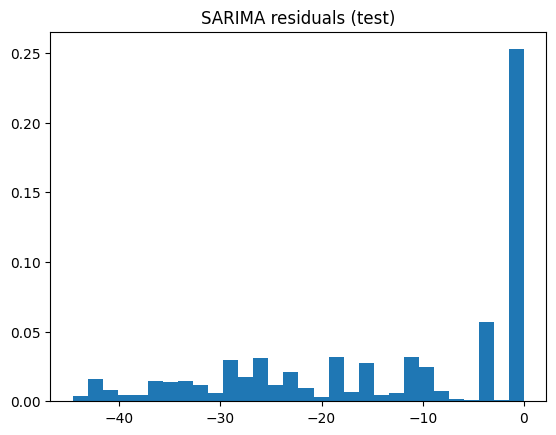

<Figure size 640x480 with 0 Axes>

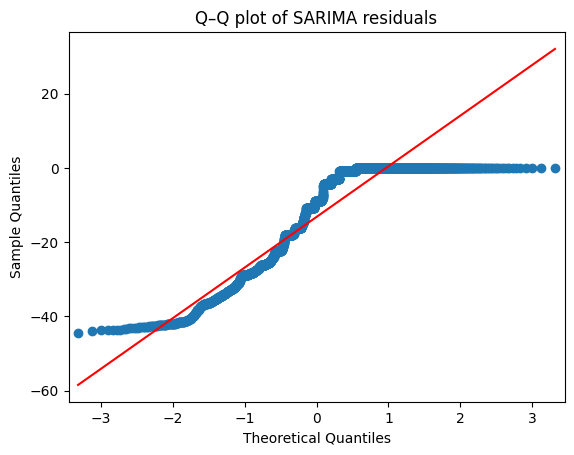

In [34]:
resid = sarima_test_df["residual"].dropna()
# Histogram
plt.figure()
plt.hist(resid, bins=30, density=True)
plt.title("SARIMA residuals (test)")
# Q-Q plot
plt.figure()
sm.qqplot(resid, line="s")
plt.title("Q–Q plot of SARIMA residuals")
sw_stat, sw_p = stats.shapiro(resid)
print("Shapiro–Wilk p-value:", sw_p)

### **XgBoost Model**

In [35]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
import matplotlib.pyplot as plt

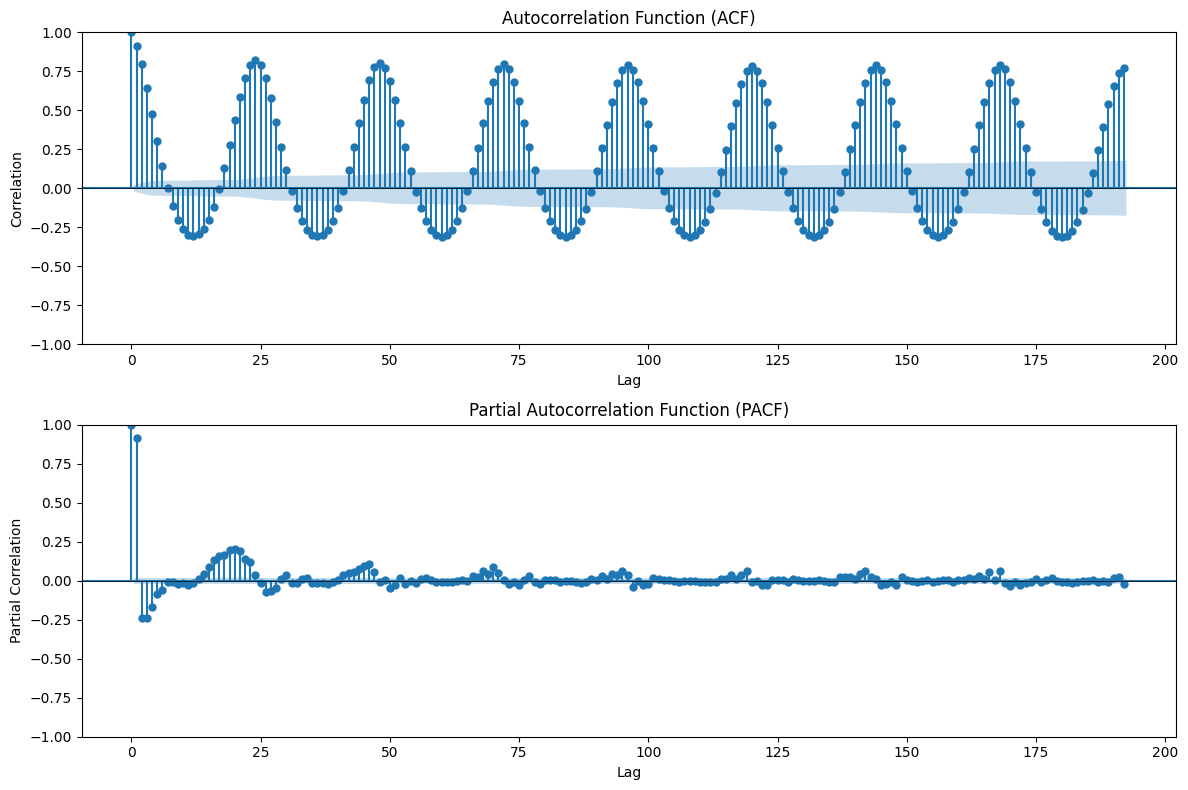

In [36]:
# Plot ACF and PACF
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# ACF plot
plot_acf(pv_raw['pv_generation'], ax=ax1, lags=192, alpha=0.05)
ax1.set_title('Autocorrelation Function (ACF)')
ax1.set_xlabel('Lag')
ax1.set_ylabel('Correlation')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# PACF plot
plot_pacf(pv_raw['pv_generation'], ax=ax2, lags=192, alpha=0.05, method='ywm')
ax2.set_title('Partial Autocorrelation Function (PACF)')
ax2.set_xlabel('Lag')
ax2.set_ylabel('Partial Correlation')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

In [37]:
target_col = "pv_generation"
pipeline_1_xg = {"model_type": "tabular", 
"target_col": target_col,
"preprocessing": [Standardize(), 
                LagFeatures(target_col=target_col, lags=[1]),
                WeatherFeatures(latitude=54.322933, longitude=9.615820, variables=["temperature_2m","shortwave_radiation","cloud_cover"]),
                CalendarFeatures(features=["hour", "dayofweek", "month"], cyclical=True),
                GermanHoliday(subdiv="SH")],
"splitter":splitter,
"model": lambda **kw: XGBModel(**kw), 
"hyperparams": {"n_estimators": [50, 100], "max_depth": [3, 6]}}

pipeline_2_xg = {"model_type": "tabular", 
"target_col": target_col,
"preprocessing": [LagFeatures(target_col=target_col, lags=[1])],
"splitter":splitter,
"model": lambda **kw: XGBModel(**kw), 
"hyperparams": {"n_estimators": [50, 100], "max_depth": [3, 6]}}

xgboost_pipelines = [pipeline_1_xg, pipeline_2_xg]

In [38]:
results_xgboost, best_hp_xgboost, best_prep_xgboost = run_pipelines_hyperparam(pv_raw, xgboost_pipelines, {"rmse":rmse,"mbe":mbe})


Running pipeline 1

Running pipeline 2


In [39]:
results_xgboost.sort_values("rmse", ascending=True).head()

,pipeline_idx,preprocessing,n_estimators,max_depth,rmse,mbe,elapsed_sec,train_rmse,train_mbe
0,1,Standardize + LagFeatures + WeatherFeatures + ...,50,3,4.752035,-0.033613,0.189184,3.097067,-0.000208
1,1,Standardize + LagFeatures + WeatherFeatures + ...,100,3,4.904784,0.084347,0.035490,2.647860,-0.000418
2,1,Standardize + LagFeatures + WeatherFeatures + ...,50,6,4.905709,0.151429,0.036209,1.333547,-0.001151
3,1,Standardize + LagFeatures + WeatherFeatures + ...,100,6,5.007844,0.151069,0.065510,0.673196,-0.000010
4,2,LagFeatures,50,3,6.746491,-0.302868,0.016339,5.076730,-0.000161


In [40]:
format_for_csv(results_xgboost.head().drop("preprocessing",axis=1)).sort_values("rmse")

,pipeline_idx,n_estimators,max_depth,rmse,mbe,elapsed_sec,train_rmse,train_mbe
0,1,50,3,4.75,-0.03,0.19,3.10,-0.00
1,1,100,3,4.90,0.08,0.04,2.65,-0.00
2,1,50,6,4.91,0.15,0.04,1.33,-0.00
3,1,100,6,5.01,0.15,0.07,0.67,-0.00
4,2,50,3,6.75,-0.30,0.02,5.08,-0.00


In [44]:
if SAVE:
    format_for_csv(results_xgboost.head().drop("preprocessing",axis=1)).sort_values("rmse").to_csv(DATA_DIR/"pv_xgboost_Summary.csv",index=False)

In [41]:
from copy import deepcopy
pipelines = []
for n in range(1, 15):  # n from 1 to 12
    pipeline = {
        "model_type": "tabular",
        "target_col": target_col,
        "preprocessing": [
            LagFeatures(target_col=target_col, lags=[1] + [12 * i for i in range(1, n+1)]),
            WeatherFeatures(latitude=54.322933, longitude=9.615820, variables=["temperature_2m","shortwave_radiation","cloud_cover"]),
            CalendarFeatures(features=["hour", "dayofweek", "month"], cyclical=True),
                GermanHoliday(subdiv="SH")
        ],
        "splitter": splitter,
        "model": lambda **kw: XGBModel(**kw),
        "hyperparams": {"n_estimators": [100], "max_depth": [3]}
    }
    
    pipelines.append(deepcopy(pipeline))

In [42]:
results_xgboost2, best_hp_xgboost2, best_prep_xgboost2 = run_pipelines_hyperparam(pv_raw, pipelines, {"rmse":rmse,"mbe":mbe})


Running pipeline 1

Running pipeline 2

Running pipeline 3

Running pipeline 4

Running pipeline 5

Running pipeline 6

Running pipeline 7

Running pipeline 8

Running pipeline 9

Running pipeline 10

Running pipeline 11

Running pipeline 12

Running pipeline 13

Running pipeline 14


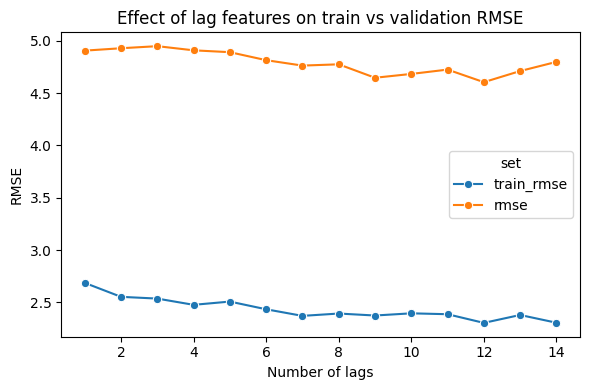

In [43]:
df = results_xgboost2.sort_values("pipeline_idx")
df["num_lags"] = df["pipeline_idx"].astype(int)
df_plot = df[["num_lags", "train_rmse", "rmse"]].sort_values("num_lags")
df_long = df_plot.melt(
    id_vars="num_lags",
    value_vars=["train_rmse", "rmse"],
    var_name="set",
    value_name="RMSE",
)
plt.figure(figsize=(6, 4))
sns.lineplot(
    data=df_long,
    x="num_lags",
    y="RMSE",
    hue="set",
    marker="o",
)
plt.xlabel("Number of lags")
plt.ylabel("RMSE")
plt.title("Effect of lag features on train vs validation RMSE")
plt.tight_layout()
plt.show()

### **LSTM Model**

In [46]:
preprocessors_lstm_e = [Standardize(), 
                LagFeatures(target_col=target_col, lags=[1, 2, 3, 24, 168]), 
                WeatherFeatures(latitude=54.322933, longitude=9.615820, variables=["temperature_2m","shortwave_radiation","cloud_cover"]),
                CalendarFeatures(features=["hour", "dayofweek", "month"], cyclical=True), 
                ReshapeToSequence(target_col=target_col, seq_len=24)]

def lstm_factory_elec(**kwargs):
    df_p = pv_raw.copy()  # must be DataFrame so LagFeatures uses column 'elecmeter', not index
    for p in preprocessors_lstm_e:
        p.fit(df_p)
        df_p = p.transform(df_p)
    if isinstance(df_p, tuple):
        X, y = df_p
        return LSTM_Model(input_size=X.shape[2], **kwargs)
    return LSTM_Model(input_size=df_p.shape[1], **kwargs)

# pipeline_1_lstm = {"model_type": "tensor", 
#         "target_col": target_col,
#         "preprocessing": preprocessors_lstm_e, 
#         "splitter": TimeSeriesSplitter().transform,
#          "model": lstm_factory_elec, 
#          "hyperparams": {"hidden_size": [16, (16, 32), (16, 32, 12)], "epochs": [50,100], "patience": [5,15], "dropout": [0.1]}}

pipeline_1_lstm = {"model_type": "tensor", 
        "target_col": target_col,
        "preprocessing": preprocessors_lstm_e, 
        "splitter": splitter,
         "model": lstm_factory_elec, 
         "hyperparams": {"hidden_size": [16, 32],"num_layers":[2,4], "epochs": [50,100], "patience": [5,15], "dropout": [0.1],"lr":[0.001]}}



In [47]:
results_LSTM, best_hp_lstm, best_prep_lstm = run_pipelines_hyperparam(pv_raw, [pipeline_1_lstm], {"rmse":rmse,"mbe":mbe})


Running pipeline 1


In [48]:
results_LSTM.sort_values("rmse", ascending=True).head()

,pipeline_idx,preprocessing,hidden_size,num_layers,epochs,patience,dropout,lr,rmse,mbe,elapsed_sec,train_rmse,train_mbe,history
0,1,Standardize + LagFeatures + WeatherFeatures + ...,16,2,100,15,0.1,0.001,5.174274,0.257949,7.230592,4.125691,0.180411,"{'train_loss': [0.8721982281941634, 0.38180436..."
1,1,Standardize + LagFeatures + WeatherFeatures + ...,16,2,50,5,0.1,0.001,5.318702,-0.308078,3.099669,4.644370,-0.088336,"{'train_loss': [0.8301779834123758, 0.35541864..."
2,1,Standardize + LagFeatures + WeatherFeatures + ...,32,2,50,5,0.1,0.001,5.453665,0.257462,1.315107,4.440790,0.028380,"{'train_loss': [0.48048085616185116, 0.1853602..."
3,1,Standardize + LagFeatures + WeatherFeatures + ...,32,2,100,15,0.1,0.001,5.456495,-0.197006,4.140966,4.095662,-0.054644,"{'train_loss': [0.6428319853085738, 0.22750791..."
4,1,Standardize + LagFeatures + WeatherFeatures + ...,32,2,100,5,0.1,0.001,5.460750,1.113394,2.173243,4.352395,0.619558,"{'train_loss': [0.583099156159621, 0.202247291..."


In [49]:
format_for_csv(results_LSTM.head().drop(["preprocessing","history"],axis=1),decimal_places=3).sort_values("rmse")

,pipeline_idx,hidden_size,num_layers,epochs,patience,dropout,lr,rmse,mbe,elapsed_sec,train_rmse,train_mbe
0,1,16,2,100,15,0.100,0.001,5.174,0.258,7.231,4.126,0.180
1,1,16,2,50,5,0.100,0.001,5.319,-0.308,3.100,4.644,-0.088
2,1,32,2,50,5,0.100,0.001,5.454,0.257,1.315,4.441,0.028
3,1,32,2,100,15,0.100,0.001,5.456,-0.197,4.141,4.096,-0.055
4,1,32,2,100,5,0.100,0.001,5.461,1.113,2.173,4.352,0.620


In [50]:
if SAVE:
    format_for_csv(results_LSTM.head().drop(["preprocessing","history"],axis=1),decimal_places=3).sort_values("rmse").to_csv(DATA_DIR/"pv_lstm_Summary.csv",index=False)

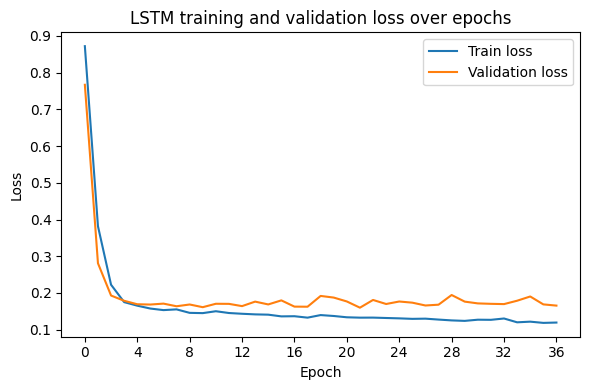

In [51]:
df_lstm = pd.DataFrame(results_LSTM.sort_values("rmse", ascending=True).history[0])
plt.figure(figsize=(6, 4))
plt.plot(df_lstm.index, df_lstm["train_loss"], label="Train loss")
plt.plot(df_lstm.index, df_lstm["val_loss"],   label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM training and validation loss over epochs")
plt.legend()
# Force integer epoch ticks
epochs = df_lstm.index.to_numpy()
plt.xticks(np.arange(0, len(df_lstm), 4))  # or np.arange(len(df_lstm)) if you prefer
plt.tight_layout()
plt.show()

### Compare all models on test set

Use the best hyperparameters from validation to evaluate each model once on the **test set** (RMSE and MBE).

In [36]:
# One entry per model: (name, data, pipelines_list, results_df, best_hyperparameters)
test_configs = [
    ("Persistence", pv_raw, pipelines_persistence, results_persistence, best_hp_persistence),
    ("SARIMA", pv_raw["pv_generation"], sarima_piplines, results_SARIMA, best_hp_sarima),
    ("XGBoost", pv_raw, xgboost_pipelines, results_xgboost, best_hp_xgboost),
    ("LSTM", pv_raw, [pipeline_1_lstm], results_LSTM, best_hp_lstm),
]
test_metrics = {"rmse": rmse, "mbe": mbe}
comparison_test = compare_models_on_test(test_configs, metric_fn=test_metrics)
comparison_test

,model,rmse,mbe,elapsed_sec,train_rmse,train_mbe,history
0,Persistence,23.778125,16.273080,0.000253,5.495280,8.178438e-19,NaN
1,SARIMA,19.020532,13.415378,5.214568,4.343425,-2.503156e-01,NaN
2,XGBoost,1.661285,-0.163184,0.021804,3.097067,-2.078318e-04,NaN
3,LSTM,2.440556,0.613882,7.375840,4.024814,1.952288e-01,"{'train_loss': [0.7849427305735075, 0.38684756..."


In [37]:
def format_for_csv(df, decimal_places=2):
    out = df.copy()
    for col in out.select_dtypes(include=["number"]).columns:
        if out[col].dtype in ("int64", "int32"):
            out[col] = out[col].apply(lambda x: f"{int(x):,}")
        else:
            out[col] = out[col].apply(lambda x: f"{x:,.{decimal_places}f}")
    return out

In [38]:
format_for_csv(comparison_test.drop(["history"],axis=1).sort_values("rmse")).to_csv(DATA_DIR/"pv_forecast_summary.csv",index=False)

In [39]:
# Best model's test forecast (for optimizers)
best_name, forecast_df = best_model_test_forecast(
    test_configs, comparison_test, primary_metric="rmse"
)
print(f"Best model: {best_name}")

# Save forecast to CSV (only forecast column for optimizers; keep actual for reference if you want)
forecast_df.to_csv(ROOT / "Data" / "pv_forecast_test.csv")
# Or only the forecast column:
forecast_df.to_csv(ROOT / "Data" / "pv_forecast_for_optimizer.csv")

Best model: XGBoost
